LISTA 4 - PROCESY POISSONA

In [5]:
import numpy as np
import math as m
import matplotlib.pyplot as plt
import scipy.stats as sc

In [6]:
def S_n1(T, lam=2):
    S_n = []
    t = 0
    I = 0
    while T >= t:
        U = np.random.random()
        dt = -1/lam * m.log(U)
        t += dt
        I = I + 1
        S_n.append(t)
    return S_n

def S_n2(T, lam=2):
    n = np.random.poisson(lam=lam*T)
    if n == 0:
        return np.array([])
    U = np.random.uniform(high=T, size=n)
    S_n = np.sort(U)
    return S_n

def N_t(S_n, t):
    return np.sum(S_n <= t)


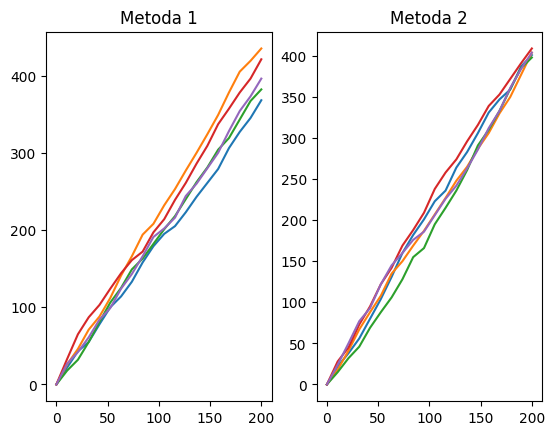

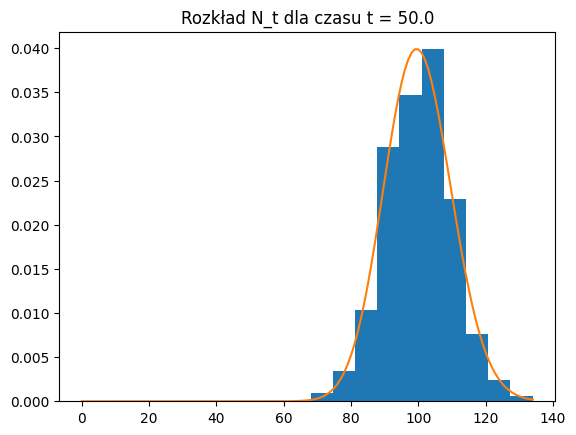

Wartości średnie 100.07, 100.0, wariancje: 96.14, 100.0


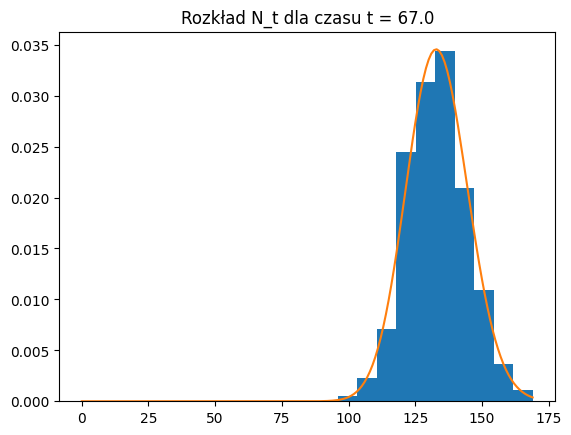

Wartości średnie 133.28, 133.0, wariancje: 131.04, 133.0


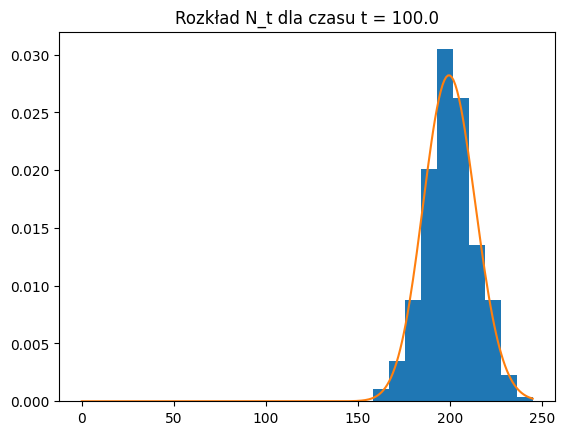

Wartości średnie 200.01, 200.0, wariancje: 186.04, 200.0


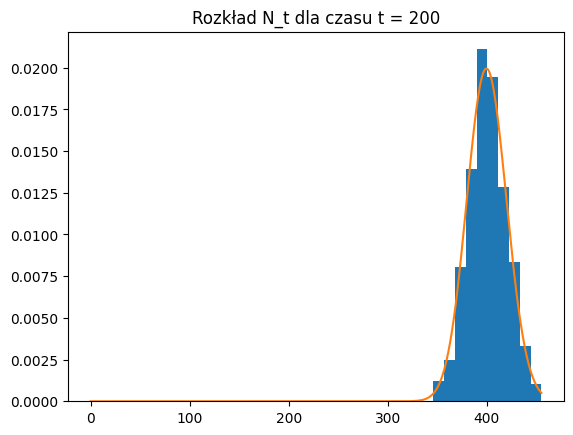

Wartości średnie 400.47, 400, wariancje: 370.62, 400


In [14]:
T = 200
n = 20
lam = 2
Poiss1 = S_n1(T, lam)
Poiss2 = S_n2(T, lam)
t = np.linspace(0, T, n)
traj_1 = np.empty(n)
traj_2 = np.empty(n)

fig, ax = plt.subplots(1, 2)
for k in range(5):
    Poiss1 = S_n1(T, lam)
    Poiss2 = S_n2(T, lam)
    traj1 = [N_t(Poiss1, ti) for ti in t]
    traj2 = [N_t(Poiss2, ti) for ti in t]
    ax[0].plot(t, traj1, label='Trajektoria {k}')
    ax[0].set_title('Metoda 1')
    ax[1].plot(t, traj2, label='Trajektoria {k}')
    ax[1].set_title('Metoda 2')
plt.show()

list_of_T = [T/4, T/3, T/2, T]
nt_list = [[], [], [], []]
N = 1000
s = []
for k in range(N):
    s.append(S_n2(T, lam))

for i in range(4):
    for element in s:
        nt_list[i].append(N_t(element, list_of_T[i]))

for i in range(len(list_of_T)):
    x = np.arange(0, max(nt_list[i]) + 1)
    y = sc.poisson.pmf(x, lam*list_of_T[i])
    plt.hist(nt_list[i],density=True)
    plt.title(f"Rozkład N_t dla czasu t = {np.round(list_of_T[i])}")
    plt.plot(x, y, label='Probability density mass function')
    plt.show()
    var_theory = lam*list_of_T[i]
    mean_theory = var_theory
    var_real = np.var(nt_list[i])
    mean_real = np.mean(nt_list[i])
    print(f'Wartości średnie {np.round(mean_real, 2)}, {np.round(mean_theory)}, wariancje: {np.round(var_real, 2)}, {np.round(var_theory)}')
    

    

In [29]:
def poisson_deviation(N_t, t, lam):
    return N_t - t * lam

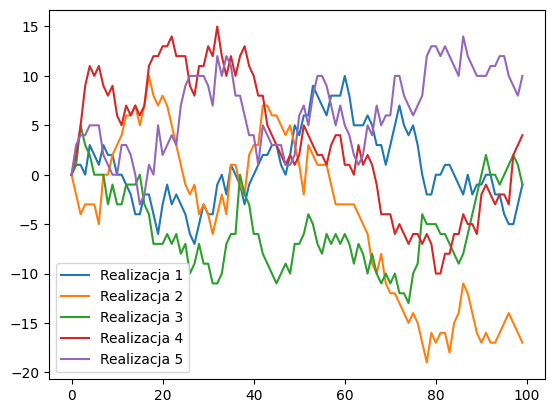

Variance = 0.0, mean = 0.0
Variance = 71.423319, mean = 0.041
Variance = 143.184775, mean = 0.065
Variance = 210.246396, mean = 0.402
Variance = 295.83174399999996, mean = -0.016


In [ ]:
lam = 3
T = 100
t = np.arange(0, T, 1)
for k in range(5):
    poiss = S_n1(T, lam=lam)
    traj = [N_t(poiss, ti) for ti in t]
    plt.plot(t, poisson_deviation(traj, t, lam=lam), label=f'Realizacja {k+1}')
plt.legend()
plt.show()

t_k = np.linspace(0, T, 5)
N = 1000
results = [[] for _ in t_k]

for _ in range(N):
    S = S_n1(T, lam)
    
    for i, t in enumerate(t_k):
        N_tilde = poisson_deviation(N_t(S, t), t, lam)
        results[i].append(N_tilde)
    
for r in results:
    print(f'Wariancja = {np.var(r)}, wartość średnia = {np.mean(r)}')




# Wartości teoretyczne

Interesuje nas $ E[\tilde{N_t}]$ i $ Var[\tilde{N_t}] $

Własność liniowości wartości oczekiwanej:

$ E[\tilde{N_t}] = E[N_t - \lambda t] = E[N_t] - E[\lambda t] = 0$

$\lambda t$ nie jest zmienną losową, zatem mamy:

$ Var[\tilde{N_t}] = Var[N_t - \lambda t]= Var[N_t] = \lambda t$

## 3. Własności martyngału

In [ ]:
T = 100
lam = 4
s = np.linspace(1, T - 20, 5)
S = S_n1(T, lam=4)
N_s = [N_t(S, si) for si in s]

N = 1000
for _ in s:
    for _ in range(N):
        N_t = 
